# Week 2 — Notebook 1: Market Data Loading

In this notebook you will:
- Define project constants (paths, tickers, dates)
- Download OHLCV data for every market symbol and save it to `data/raw/`
- Explore the downloaded data and compute basic return statistics
- Compare multiple symbols with normalised return plots

Fill in every `# TODO` cell before moving to `technical_indicators.ipynb`.

---

## 0. Install & Import Libraries

In [2]:
# !pip install yfinance pandas numpy matplotlib  # uncomment on Colab / fresh env

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

print('Libraries imported!')

Libraries imported!


---

## 1. Project Configuration

Define all constants that the project relies on. These same constants are used in every notebook and script this week, so get them right here first.

| Constant | Purpose |
|---|---|
| `BASE_DIR` | Root of the project (notebook's working directory) |
| `RAW_DIR` | `BASE_DIR/data/raw` — raw OHLCV CSVs |
| `PROCESSED_DIR` | `BASE_DIR/data/processed` — feature-engineered CSVs |
| `START_DATE` | Earliest date to download (`"2015-01-01"`) |
| `END_DATE` | `None` → today |
| `MARKET_SYMBOLS` | Dict: market name → list of Yahoo Finance ticker strings |

> 💡 Use `Path.cwd()` as the base when running inside a notebook.

In [4]:
# TODO 1.1 — Define directory paths and create them on disk
BASE_DIR      = Path.cwd()
RAW_DIR       = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

print('RAW_DIR      :', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

RAW_DIR      : /content/data/raw
PROCESSED_DIR: /content/data/processed


In [5]:
# TODO 1.2 — Define the date range and market symbol universe
START_DATE =      '2015-01-01'
END_DATE   =      None

#Load the market symbols in the readme as dictionary here
MARKET_SYMBOLS = {
    'india':  ['^NSEI',
        '^BSESN',
        'RELIANCE.NS',
        'TCS.NS',
        'INFY.NS'],
    'us':     ['^GSPC',
        '^IXIC',
        'SPY',
        'AAPL',
        'MSFT',
        'NVDA',
        'TSLA'],
    'crypto': ['BTC-USD',
        'ETH-USD'],
    'forex':  ['EURUSD=X',
        'JPY=X'],
}

print('Markets :', list(MARKET_SYMBOLS.keys()))
print('Symbols :', sum(len(v) for v in MARKET_SYMBOLS.values()), 'total')

Markets : ['india', 'us', 'crypto', 'forex']
Symbols : 16 total


In [6]:
# TODO 1.3 — Implement safe_symbol()
# Converts a ticker into a filesystem-safe filename stem.
# Rules: drop '^', replace '.' '-' '=' with '_'
# Examples:
#   '^NSEI'       -> 'NSEI'
#   'RELIANCE.NS' -> 'RELIANCE_NS'
#   'BTC-USD'     -> 'BTC_USD'
#   'EURUSD=X'    -> 'EURUSD_X'

def safe_symbol(symbol: str) -> str:
  return (
        symbol
        .replace('^', '')
        .replace('.', '_')
        .replace('-', '_')
        .replace('=', '_')
    )

# Smoke-test
assert safe_symbol('^NSEI')       == 'NSEI'
assert safe_symbol('RELIANCE.NS') == 'RELIANCE_NS'
assert safe_symbol('BTC-USD')     == 'BTC_USD'
assert safe_symbol('EURUSD=X')    == 'EURUSD_X'
print('safe_symbol() passed!')

safe_symbol() passed!


---

## 2. OHLCV Data Structure

Every downloaded file will have these columns (lowercase, normalised by us):

| Column | Description |
|---|---|
| `date` | Trading date |
| `open` | Price at market open |
| `high` | Intraday high |
| `low` | Intraday low |
| `close` | Price at market close |
| `adj_close` | Close adjusted for dividends and splits |
| `volume` | Shares / contracts traded |
| `symbol` | Ticker string (added by the download function) |

> The **close** price is used for all technical indicators. `adj_close` is preferred for long-term return calculations.

---

## 3. Download All Market Symbols → `data/raw/`

Implement the download pipeline step by step.

Each raw CSV must have lowercase column names, a `symbol` column, and be saved as `data/raw/<safe_symbol>.csv`.

In [7]:
# TODO 3.1 — Implement download_symbol()
# Downloads and cleans OHLCV data for a single ticker.
# Steps inside the function:
#   1. Call yf.download() with auto_adjust=False, progress=False
#   2. Raise ValueError if the result is empty
#   3. Flatten MultiIndex columns: keep only the first level
#      (yfinance sometimes returns a MultiIndex when downloading one symbol)
#   4. Reset the index so 'Date' becomes a regular column
#   5. Lowercase all column names; replace spaces with underscores
#   6. Add a 'symbol' column containing the ticker string

def download_symbol(symbol: str, start: str = START_DATE, end=END_DATE) -> pd.DataFrame:
    # 1. Call yf.download() function
    data = yf.download(
    symbol,
    start=start,
    end=end,
    auto_adjust=False,
    progress=False
)

    # 2. Raise ValueError for check
    if data.empty:
      raise ValueError(f"No data returned for {symbol}")
    # 3. Flatten MultiIndex
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    # 4. Reset index
    data = data.reset_index()

    # 5. Normalise column names

    data.columns = [
        col.lower().replace(" ", "_")
        for col in data.columns
    ]


    # 6. Add symbol column
    data["symbol"] = symbol

    return data

# Quick test
test_df = download_symbol('SPY')
print(test_df.shape)
print(test_df.columns.tolist())
test_df.head()

(2877, 8)
['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'symbol']


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,170.124969,205.429993,206.880005,204.179993,206.380005,121465900,SPY
1,2015-01-05,167.052582,201.720001,204.369995,201.350006,204.169998,169632600,SPY
2,2015-01-06,165.479126,199.820007,202.720001,198.860001,202.089996,209151400,SPY
3,2015-01-07,167.541245,202.309998,202.720001,200.880005,201.419998,125346700,SPY
4,2015-01-08,170.514236,205.899994,206.160004,203.990005,204.009995,147217800,SPY


In [8]:
# TODO 3.2 — Download every symbol and save to RAW_DIR
# Use a try/except so one failed ticker does not stop the loop.

for market, symbols in MARKET_SYMBOLS.items():
    for symbol in symbols:
        try:
          df = download_symbol(symbol)
        except Exception as e:
            print(f"Failed: {symbol} -> {e}")

---

## 4. Load & Explore a Single Symbol

Before computing indicators, get familiar with the raw data for one symbol.

In [9]:
# TODO 4.1 — Load SPY (or any symbol you like) from RAW_DIR
# Parse 'date' as datetime, sort ascending.
df['date']=pd.to_datetime(df['date'])
df=df.sort_values('date')


print('Shape :', df.shape)
print('Dtypes:\n', df.dtypes)
df.head()

Shape : (2979, 8)
Dtypes:
 date         datetime64[ns]
adj_close           float64
close               float64
high                float64
low                 float64
open                float64
volume                int64
symbol               object
dtype: object


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-01,119.672997,119.672997,119.672997,119.672997,119.672997,0,JPY=X
1,2015-01-02,119.870003,119.870003,120.736000,119.835999,119.889999,0,JPY=X
2,2015-01-05,120.433998,120.433998,120.608002,119.411003,120.389000,0,JPY=X
3,2015-01-06,119.425003,119.425003,119.497002,118.680000,119.416000,0,JPY=X
4,2015-01-07,118.672997,118.672997,119.639000,118.674004,118.674004,0,JPY=X


In [10]:
# TODO 4.2 — Compute and print the following statistics
#   1. Mean daily return (pct_change of close)
#   2. Daily return standard deviation (volatility)
#   3. Annualised volatility  →  daily_std * sqrt(252)
#   4. Total cumulative return over the full period
#   5. Date of the all-time high close
#   6. Date of the all-time low close

close   = df['close']
daily_returns=close.pct_change()
mean_daily_return=daily_returns.mean()
daily_std=daily_returns.std()
annual_volatility=daily_std*np.sqrt(252)
total_return = (close.iloc[-1] / close.iloc[0]) - 1
high_date = df.loc[close.idxmax(), 'date']
low_date = df.loc[close.idxmin(), 'date']

# print(...)
print(f"Mean Daily Return: {mean_daily_return:.6f}")
print(f"Daily Volatility: {daily_std:.6f}")
print(f"Annualised Volatility: {annual_volatility:.6f}")
print(f"Total Return: {total_return:.2%}")
print(f"All-Time High Date: {high_date}")
print(f"All-Time Low Date: {low_date}")

Mean Daily Return: 0.000114
Daily Volatility: 0.005610
Annualised Volatility: 0.089062
Total Return: nan%
All-Time High Date: 2024-07-04 00:00:00
All-Time Low Date: 2016-08-18 00:00:00


/tmp/ipykernel_3460/2517767006.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns=close.pct_change()


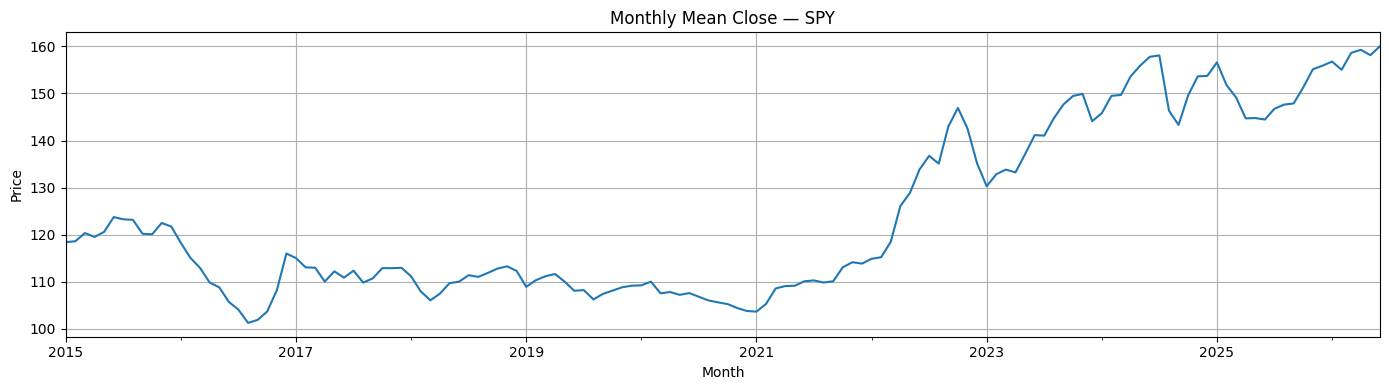

In [11]:
# TODO 4.3 — Resample close to monthly mean and plot as a line chart

monthly_close = df.set_index('date')['close'].resample('ME').mean()
SYMBOL='SPY'

plt.figure(figsize=(14, 4))
monthly_close.plot()
plt.title(f'Monthly Mean Close — {SYMBOL}')
plt.xlabel('Month'); plt.ylabel('Price')
plt.grid(True); plt.tight_layout(); plt.show()

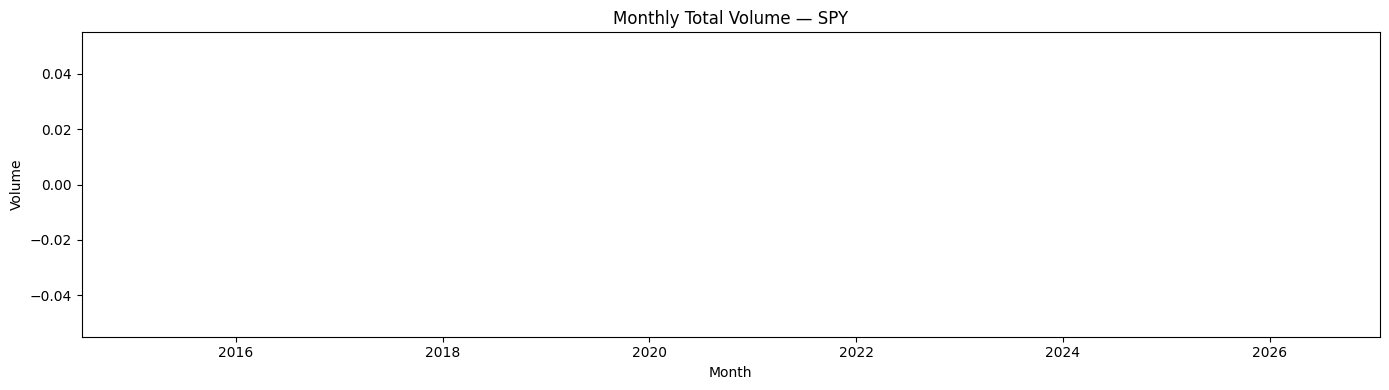

In [12]:
# TODO 4.4 — Resample volume to monthly total and plot as a bar chart

monthly_vol =df.set_index('date')['volume'].resample('ME').sum()

plt.figure(figsize=(14, 4))
plt.bar(monthly_vol.index,monthly_vol.values)
plt.title(f'Monthly Total Volume — {SYMBOL}')
plt.xlabel('Month'); plt.ylabel('Volume')
plt.tight_layout(); plt.show()

---

## 5. Multi-Symbol Comparison

Normalised cumulative returns let you compare symbols regardless of their absolute price level. Dividing each series by its first value sets every series to start at 1.0.

In [13]:
# TODO 5.1 — Load the Close price for all US symbols into one DataFrame
# Each column = one symbol. Align on date index, forward-fill any gaps.

us_closes = {}

for sym in MARKET_SYMBOLS['us']:
    path = RAW_DIR / f"{safe_symbol(sym)}.csv"

    if not path.exists():
        print(f"Missing file: {path}")
        continue

    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])

    us_closes[sym] = df.set_index('date')['close']



Missing file: /content/data/raw/GSPC.csv
Missing file: /content/data/raw/IXIC.csv
Missing file: /content/data/raw/SPY.csv
Missing file: /content/data/raw/AAPL.csv
Missing file: /content/data/raw/MSFT.csv
Missing file: /content/data/raw/NVDA.csv
Missing file: /content/data/raw/TSLA.csv


In [14]:
# TODO 5.2 — Normalise so each series starts at 1.0, then plot all on one chart
normalized = us_closes / us_closes.iloc[0]

plt.figure(figsize=(14, 6))

for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)
plt.title('Normalised Cumulative Return — US Symbols')
plt.ylabel('Growth of $1 invested'); plt.xlabel('Date')
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

AttributeError: 'dict' object has no attribute 'iloc'

In [16]:
# TODO 5.3 — Repeat for India symbols

india_closes = {}
for sym in MARKET_SYMBOLS['india']:
    india_closes[sym] = pd.read_csv(f'{RAW_DIR}/{sym}.csv',
                                    parse_dates=['date'],
                                    index_col='date')['close']

india_closes = pd.DataFrame(india_closes).ffill()

# plot normalised series
normalized = india_closes.div(india_closes.iloc[0], axis=1)

plt.figure(figsize=(14, 6))

for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)

plt.title('Normalised Cumulative Return — India Symbols')
plt.ylabel('Growth of $1 invested')
plt.xlabel('Date')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/data/raw/^NSEI.csv'

---
